# Detección de Inyecciones SQL mediante técnicas de procesamiento de lenguaje natural y aprendizaje automático

## Introducción
Por Gonzalo Benito, Lic. en Sistemas de Información, Universidad Nacional de Luján, Argentina.

Este trabajo propone desarrollar un sistema de detección de ataques de Inyección SQL utilizando técnicas de procesamiento de lenguaje natural (NLP) y algoritmos de machine learning. Se empleó un dataset obtenido de Kaggle que contiene sentencias SQL etiquetadas como peligrosas o benignas. La metodología incluyó la transformación de las sentencias en vectores mediante **embeddings semánticos** utilizando modelos pre-entrenados, seguida de la aplicación de **PCA** para reducir dimensionalidad y algoritmos de clasificación como Support Vector Machines (SVM), Random Forest y Logistic Regression. El objetivo fue evaluar y comparar el desempeño de los modelos mediante métricas de precisión, recall y F1-score, y **demostrar si es posible la detección de ataques de inyección SQL mediante técnicas de Machine Learning**.

#### Detalles de lo que se incluirá en este trabajo
La metodología seguirá un enfoque basado en **embeddings semánticos** generados por modelos de lenguaje pre-entrenados, específicamente usando 'all-MiniLM-L6-v2'. Con este método, cada sentencia se transforma en un vector denso de 384 dimensiones que captura el significado semántico de la consulta SQL. A diferencia de las representaciones basadas en frecuencia (como TF-IDF), los embeddings pueden detectar patrones maliciosos más sutiles y generalizar mejor a variantes de ataques no vistas anteriormente. Se aplicará **PCA** para reducir la dimensionalidad y visualizar los datos, seguido de la evaluación con algoritmos de clasificación como Support Vector Machines (SVM), Random Forest y Logistic Regression. El objetivo es evaluar y comparar el desempeño de las distintas configuraciones de los modelos, mediante las métricas de precisión más usadas, y demostrar si es posible la detección de ataques de inyección SQL mediante técnicas de Machine Learning.

## Descripción del dataset
El dataset utilizado es 'SQL Injection Dataset' de Syed Saqlain Hussain (Kaggle), con 30.920 filas y dos columnas principales: `Sentence` (consulta SQL o texto) y `Label` (0=benigna, 1=inyección).

| Atributo | Tipo | Descripción |
| -------- | ---- | ----------- |
| Sentence | texto | Consulta SQL completa o texto |
| Label | categórica | 0 = no inyección, 1 = inyección SQL |

De la variable Sentence se obtendrá el conjunto de features durante la fase de Feature Engineering, utilizando **embeddings semánticos** con modelos pre-entrenados como 'all-MiniLM-L6-v2'.

Link del dataset: https://www.kaggle.com/datasets/syedsaqlainhussain/sql-injection-dataset

## Instalación de librerías necesarias

In [1]:
# Dependencias básicas
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install numpy==1.26.4
%pip install imbalanced-learn

# Librerías específicas para embeddings
%pip install sentence-transformers
%pip install torch  # Requerido por sentence-transformers

import pandas as pd
import gc  # Para gestión de memoria
import numpy as np

# Configuración para optimizar memoria
pd.options.mode.copy_on_write = True  # Evita copias innecesarias en pandas


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note

### Importación del dataset y selección de features

In [2]:
data: pd.DataFrame = pd.read_csv(
    "./data/SQLiV3.csv"
)  # El dataset debe tener columnas 'Sentence' y 'Label'
data

,Sentence,Label,Unnamed: 2,Unnamed: 3
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN
1,create user name identified by pass123 tempora...,NaN,1,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN
...,...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,NaN,NaN
30915,DELETE FROM tomorrow,0,NaN,NaN
30916,SELECT wide ( s ) FROM west,0,NaN,NaN
30917,SELECT * FROM ( SELECT slide FROM breath ),0,NaN,NaN


In [3]:
data = data[["Sentence", "Label"]].copy()  # Seleccionar solo las columnas necesarias
data["Sentence"] = data["Sentence"].astype(str)
data["length"] = data["Sentence"].apply(len)
data

,Sentence,Label,length
0,""" or pg_sleep ( __TIME__ ) --",1,33
1,create user name identified by pass123 tempora...,NaN,89
2,AND 1 = utl_inaddr.get_host_address ( ...,1,218
3,select * from users where id = '1' or @ @1 ...,1,90
4,"select * from users where id = 1 or 1#"" ( ...",1,85
...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,37
30915,DELETE FROM tomorrow,0,20
30916,SELECT wide ( s ) FROM west,0,28
30917,SELECT * FROM ( SELECT slide FROM breath ),0,44


## Preprocesamiento

### Limpieza de missing values y ruido

In [4]:
# Eliminar filas donde 'Sentence' es NaN
data = data.dropna(subset=["Sentence"])

# Me quedo solo con las clases 0 y 1 (por si hay algún otro valor en 'Label', como un string)
data = data[data["Label"].isin(["0", "1"])]

## Análisis exploratorio de datos (EDA)
Exploramos la distribución de clases y longitud de sentencias.

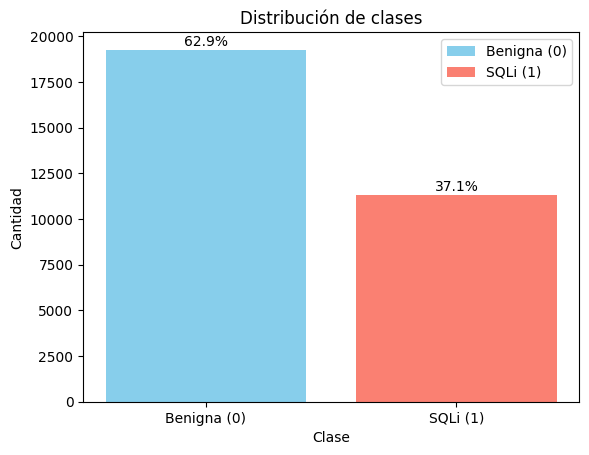

In [5]:
# Distribución de clases
import matplotlib.pyplot as plt

value_counts = data["Label"].value_counts()
percentage = (value_counts / value_counts.sum()) * 100
labels = ["Benigna (0)", "SQLi (1)"]

fig, axes = plt.subplots()
bars = axes.bar(labels, value_counts, color=["skyblue", "salmon"], label=labels)

# Texto de porcentaje arriba de cada barra
for bar, pct in zip(bars, percentage):
    axes.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{pct:.1f}%",
        ha="center",
        fontsize=10,
    )

axes.set_title("Distribución de clases")
axes.set_xlabel("Clase")
axes.set_ylabel("Cantidad")
axes.legend()
plt.show()

Las clases están desbalanceadas. La clase mayoritaria es la 0 (sentencias benignas). Recurriremos a técnicas de balanceo para solucionar este problema.

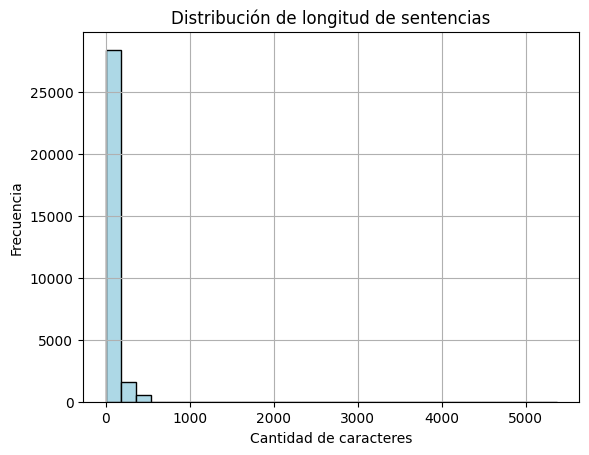

Cantidad de caracteres de la sentencia más larga: 5370


,Sentence,Label,length
19341,de]]> </email_address> <find_account_answer...,0,5370
19667,SELECT wp_posts.* FROM wp_posts LEFT JOIN wp_p...,0,559
19663,SELECT wp_posts.ID FROM wp_posts LEFT JOIN wp_...,0,529
9780,1'|| ( select 'rjis' from dual where 7696 =...,1,456
7270,"-6475"" ) ) ) or 4144 = ( selec...",1,455
...,...,...,...
628,!,1,1
19312,0,1,1
438,?,1,1
106,s,1,1


In [6]:
data["length"].hist(bins=30, color="lightblue", edgecolor="black")
plt.title("Distribución de longitud de sentencias")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")
plt.show()

print(f"Cantidad de caracteres de la sentencia más larga: {data['length'].max()}")
data_sort_by_length = data.sort_values(by="length", ascending=False)
data_sort_by_length

Vemos que la sentencia 19341 tiene una longitud atípica, 10 veces mayor que la segunda sentencia más larga. Esta es benigna. La eliminaremos del dataset por ser un outlier. Luego volvemos a mostrar el histograma de longitudes de sentencia.

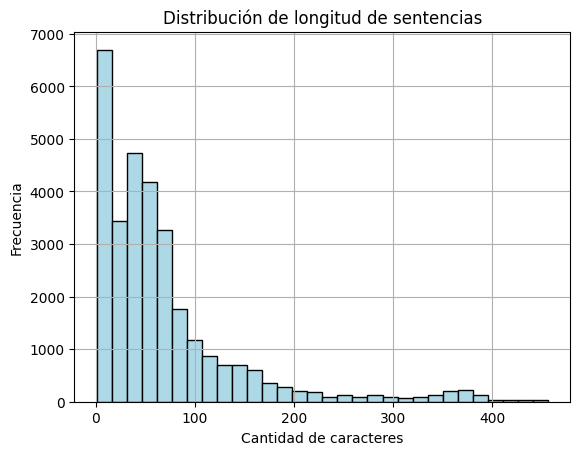

In [7]:
data = data[data["length"] <= 500]
data["length"].max()

data["length"].hist(bins=30, color="lightblue", edgecolor="black")
plt.title("Distribución de longitud de sentencias")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")
plt.show()

## Feature Engineering

Se exploran dos enfoques: TF-IDF (en otro notebook) y **embeddings semánticos** (este notebook). Los embeddings capturan el significado semántico de las sentencias SQL, mientras que TF-IDF se basa en frecuencias de n-gramas.

In [8]:
# Generación de embeddings usando sentence-transformers
from sentence_transformers import SentenceTransformer
import time

print("GENERACIÓN DE EMBEDDINGS CON SENTENCE-TRANSFORMERS:")
print("=" * 60)

# Cargar modelo pre-entrenado optimizado para tareas de clasificación
# all-MiniLM-L6-v2: 384 dimensiones, 80MB, excelente balance rendimiento/velocidad
model_name = 'all-MiniLM-L6-v2'
print(f"Cargando modelo: {model_name}")
print("Fuente: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2")

embeddings_model = SentenceTransformer(model_name)

print("\n✓ Información del modelo:")
print(f"  Dimensiones del embedding: {embeddings_model.get_sentence_embedding_dimension()}")
print(f"  Modelo: {model_name}")
print(f"  Optimizado para: clasificación de texto y similitud semántica")

# Convertir sentencias a embeddings
print("\nGenerando embeddings para todas las sentencias...")
start_time = time.time()

# Usar batch processing para mayor eficiencia
sentences = data["Sentence"].tolist()
batch_size = 32  # Ajustar según memoria disponible

embeddings_matrix = embeddings_model.encode(
    sentences, 
    batch_size=batch_size,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True  # Normalizar para mejor rendimiento en clasificación
)

end_time = time.time()

print(f"\n✓ Embeddings generados exitosamente:")
print(f"  Forma de la matriz: {embeddings_matrix.shape}")
print(f"  Tipo: {type(embeddings_matrix)}")
print(f"  Tiempo de procesamiento: {end_time - start_time:.2f} segundos")
print(f"  Memoria estimada: ~{embeddings_matrix.nbytes / 1024**2:.1f} MB")

# Verificar que no hay valores NaN
nan_count = np.isnan(embeddings_matrix).sum()
print(f"  Valores NaN: {nan_count}")

if nan_count > 0:
    print("⚠️ Detectados valores NaN, reemplazando con ceros...")
    embeddings_matrix = np.nan_to_num(embeddings_matrix, nan=0.0)

print("\n✓ OPTIMIZACIÓN: Embeddings normalizados y listos para PCA")

# Liberar modelo de memoria si es necesario
del embeddings_model
gc.collect()

/home/gbenito/universidad/TP-Final-BDM/custom_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GENERACIÓN DE EMBEDDINGS CON SENTENCE-TRANSFORMERS:
Cargando modelo: all-MiniLM-L6-v2
Fuente: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

✓ Información del modelo:
  Dimensiones del embedding: 384
  Modelo: all-MiniLM-L6-v2
  Optimizado para: clasificación de texto y similitud semántica

Generando embeddings para todas las sentencias...

✓ Información del modelo:
  Dimensiones del embedding: 384
  Modelo: all-MiniLM-L6-v2
  Optimizado para: clasificación de texto y similitud semántica

Generando embeddings para todas las sentencias...


Batches: 100%|██████████| 957/957 [01:32<00:00, 10.37it/s]




✓ Embeddings generados exitosamente:
  Forma de la matriz: (30606, 384)
  Tipo: <class 'numpy.ndarray'>
  Tiempo de procesamiento: 92.42 segundos
  Memoria estimada: ~44.8 MB
  Valores NaN: 0

✓ OPTIMIZACIÓN: Embeddings normalizados y listos para PCA


1967

In [9]:
# PREPARACIÓN DE DATOS CON EMBEDDINGS
print("PREPARANDO DATOS CON EMBEDDINGS:")
print("=" * 50)

# Usar matriz de embeddings como características
X_original = embeddings_matrix  # Matriz densa de embeddings
y_original = data["Label"].copy()

# Convertir etiquetas a tipo int8 para ahorrar memoria
y_original = y_original.astype("int8")

print("✓ X_original (embeddings):")
print(f"  Forma: {X_original.shape}")
print(f"  Tipo: {type(X_original)} (DENSO - embeddings normalizados)")
print(f"  Memoria estimada: ~{X_original.nbytes / 1024**2:.1f} MB")

print("\n✓ y_original:")
print(f"  Forma: {len(y_original)}")
print(f"  Tipo: {y_original.dtype} (int8 - ahorra RAM)")
print(f"  Memoria estimada: ~{y_original.nbytes / 1024**2:.1f} MB")

# Liberar variables innecesarias
del data["length"]  # No necesitamos más esta columna
del embeddings_matrix  # Ya está en X_original
gc.collect()

print("\n✓ Datos preparados para aplicar PCA")

PREPARANDO DATOS CON EMBEDDINGS:
✓ X_original (embeddings):
  Forma: (30606, 384)
  Tipo: <class 'numpy.ndarray'> (DENSO - embeddings normalizados)
  Memoria estimada: ~44.8 MB

✓ y_original:
  Forma: 30606
  Tipo: int8 (int8 - ahorra RAM)
  Memoria estimada: ~0.0 MB

✓ Datos preparados para aplicar PCA

✓ Datos preparados para aplicar PCA


### Ejemplo simplificado de embeddings vs TF-IDF

Los embeddings capturan significado semántico, mientras que TF-IDF se basa en frecuencias de caracteres/palabras.

**Ventajas de los embeddings:**
- Capturan relaciones semánticas entre palabras
- Mejor generalización para variantes de ataques
- Representación densa y eficiente
- Pre-entrenados en grandes corpus de texto

**Fuentes:**
- [Understanding Sentence Embeddings](https://towardsdatascience.com/understanding-sentence-embeddings-5c0fbbb4e90e)
- [Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks](https://arxiv.org/abs/1908.10084)

In [10]:
import numpy as np

# Ejemplo de diferencia entre embeddings y vectores de frecuencia
print("COMPARACIÓN: EMBEDDINGS VS TF-IDF")
print("=" * 40)

# Simulación de embeddings (vectores densos, valores continuos)
embedding_benigno = np.array([0.2, -0.1, 0.8, 0.3, -0.5])  # Sentencia benigna
embedding_sqli = np.array([-0.3, 0.9, -0.2, 0.7, 0.4])     # Sentencia SQLi

print("Embeddings (representación semántica densa):")
print(f"  Benigno: {embedding_benigno}")
print(f"  SQLi:    {embedding_sqli}")
print(f"  Dimensiones: {len(embedding_benigno)}")

# Similitud coseno entre embeddings
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity([embedding_benigno], [embedding_sqli])[0][0]
print(f"  Similitud coseno: {similarity:.3f}")

print("\nVentajas de los embeddings:")
print("- Capturan relaciones semánticas")
print("- Representación densa (no sparse)")  
print("- Pre-entrenados en grandes corpus")
print("- Mejor generalización para variantes")

COMPARACIÓN: EMBEDDINGS VS TF-IDF
Embeddings (representación semántica densa):
  Benigno: [ 0.2 -0.1  0.8  0.3 -0.5]
  SQLi:    [-0.3  0.9 -0.2  0.7  0.4]
  Dimensiones: 5
  Similitud coseno: -0.234

Ventajas de los embeddings:
- Capturan relaciones semánticas
- Representación densa (no sparse)
- Pre-entrenados en grandes corpus
- Mejor generalización para variantes


### Análisis de Componentes Principales (PCA) para Embeddings

Aplicaremos PCA a los embeddings para:
1. **Reducir dimensionalidad**: De 384 a 50 componentes principales
2. **Visualización**: Permitir análisis visual en 2D/3D  
3. **Eliminación de ruido**: Mantener solo componentes más informativos
4. **Eficiencia computacional**: Acelerar entrenamiento de modelos

**Ventajas de PCA con embeddings:**
- Los embeddings son densos (no sparse), ideal para PCA estándar
- Cada dimensión tiene significado semántico
- Mejor preservación de información con menos componentes
- Método lineal eficiente y determinístico

**Fuentes:**
- [PCA for Dimensionality Reduction](https://scikit-learn.org/stable/modules/decomposition.html#pca)
- [Principal Component Analysis Explained](https://towardsdatascience.com/principal-component-analysis-pca-explained-visually-with-zero-math-1cbf392b9e7d)

### Aplicación de PCA a embeddings

In [11]:
# APLICACIÓN DE PCA A EMBEDDINGS
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Configuración de PCA
PCA_COMPONENTS = 50  # Reducir de 384 a 50 componentes principales

print("APLICANDO PCA A EMBEDDINGS:")
print("=" * 50)

print("Aplicando PCA estándar (optimizado para matrices densas)...")

# PCA estándar es ideal para embeddings (matrices densas)
pca = PCA(n_components=PCA_COMPONENTS, random_state=0)
X_processed = pca.fit_transform(X_original)

print(f"✓ PCA aplicado: {X_original.shape[1]} → {X_processed.shape[1]} características")
print(f"✓ Varianza explicada total: {pca.explained_variance_ratio_.sum():.3f}")
print(f"✓ Tipo resultante: {type(X_processed)} (denso)")

# Mostrar información detallada de varianza
print(f"\nINFORMACIÓN DETALLADA DE PCA:")
print(f"  Componentes originales: {X_original.shape[1]} (embeddings)")
print(f"  Componentes PCA: {X_processed.shape[1]}")
print(f"  Varianza explicada: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")
print(f"  Primeros 5 componentes: {pca.explained_variance_ratio_[:5]}")

# Análisis de componentes necesarias para diferentes umbrales
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
thresholds = [0.80, 0.90, 0.95, 0.99]

print(f"\nCOMPONENTES NECESARIAS PARA DIFERENTES UMBRALES:")
for threshold in thresholds:
    if cumulative_variance[-1] >= threshold:
        components_needed = np.argmax(cumulative_variance >= threshold) + 1
        print(f"  {threshold*100:.0f}% de varianza: {components_needed} componentes")
    else:
        print(f"  {threshold*100:.0f}% de varianza: >{PCA_COMPONENTS} componentes (no alcanzado)")

# Liberar memoria de la matriz original
del X_original
gc.collect()

preprocessing_objects = {
    "pca": pca, 
    "pca_applied": True, 
    "method": "PCA", 
    "n_components": PCA_COMPONENTS
}

print(f"\n✓ Forma final de X_processed: {X_processed.shape}")
print(f"✓ Método aplicado: {preprocessing_objects['method']}")

# Nota sobre PCA
print(f"\nNOTA SOBRE PCA:")
print("- PCA es determinístico y reproducible")
print("- Método lineal eficiente para reducción de dimensionalidad")  
print("- Preserva la máxima varianza posible")
print("- Ideal para análisis de componentes principales")

# Fuentes
print(f"\nFUENTES:")
print("- PCA en scikit-learn: https://scikit-learn.org/stable/modules/decomposition.html#pca")
print("- Embeddings + PCA: https://towardsdatascience.com/pca-on-text-embeddings-b6ce5d2aca7a")

APLICANDO PCA A EMBEDDINGS:
Aplicando PCA estándar (optimizado para matrices densas)...
✓ PCA aplicado: 384 → 50 características
✓ Varianza explicada total: 0.609
✓ Tipo resultante: <class 'numpy.ndarray'> (denso)

INFORMACIÓN DETALLADA DE PCA:
  Componentes originales: 384 (embeddings)
  Componentes PCA: 50
  Varianza explicada: 0.6087 (60.87%)
  Primeros 5 componentes: [0.10100279 0.06548862 0.031404   0.02453044 0.0218191 ]

COMPONENTES NECESARIAS PARA DIFERENTES UMBRALES:
  80% de varianza: >50 componentes (no alcanzado)
  90% de varianza: >50 componentes (no alcanzado)
  95% de varianza: >50 componentes (no alcanzado)
  99% de varianza: >50 componentes (no alcanzado)

✓ Forma final de X_processed: (30606, 50)
✓ Método aplicado: PCA

NOTA SOBRE PCA:
- PCA es determinístico y reproducible
- Método lineal eficiente para reducción de dimensionalidad
- Preserva la máxima varianza posible
- Ideal para análisis de componentes principales

FUENTES:
- PCA en scikit-learn: https://scikit-le

### Visualización de componentes principales con PCA

VISUALIZACIÓN DE COMPONENTES PRINCIPALES (PCA):


/tmp/ipykernel_175168/3984550497.py:45: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(components_range, cumulative_variance, 'ro-', color='red',


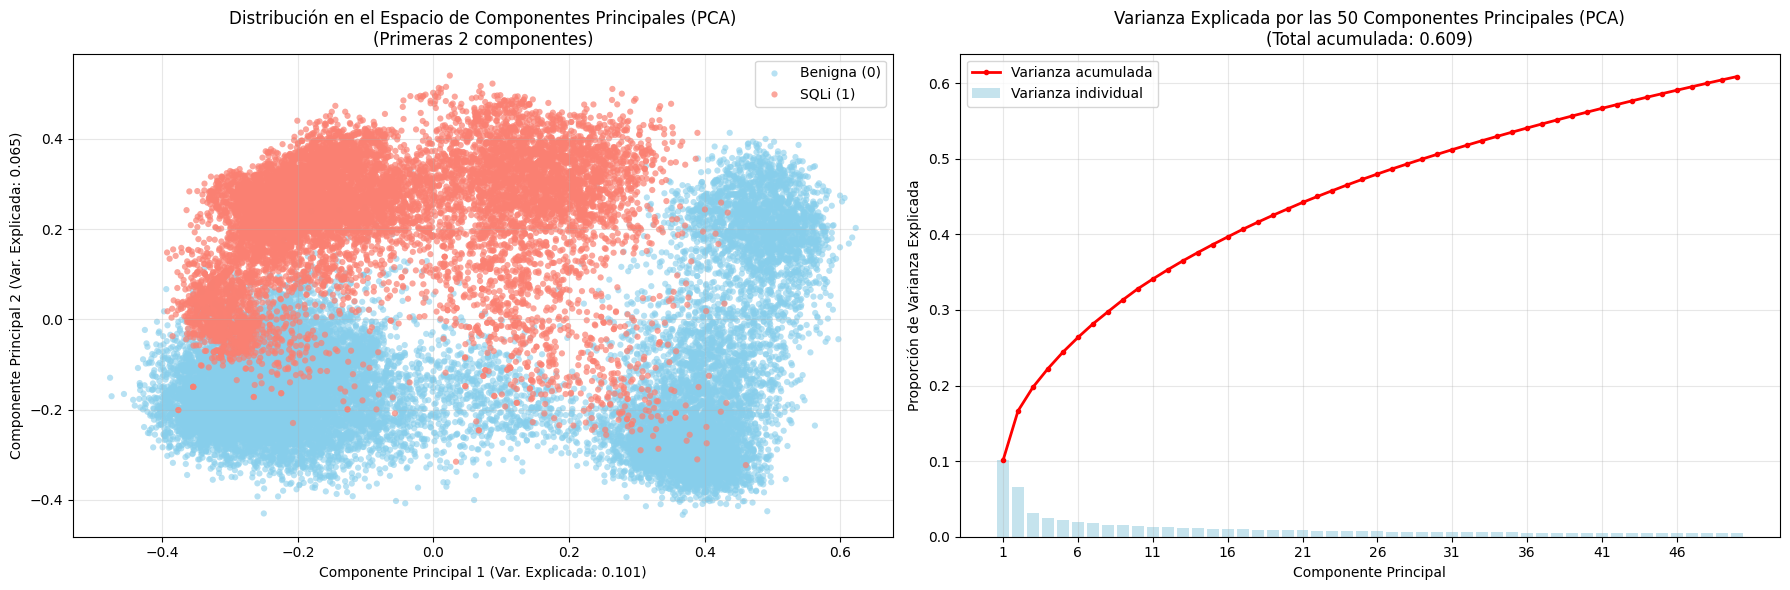


INFORMACIÓN DE COMPONENTES PCA:
Total de componentes: 50
Varianza explicada por componente 1: 0.1010
Varianza explicada por componente 2: 0.0655
Varianza total acumulada: 0.6087

ANÁLISIS DE SEPARABILIDAD:
Distancia entre centroides de clases: 0.404

FUENTES:
- Visualización PCA: https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_vs_lda.html
- Interpretación componentes principales: https://builtin.com/data-science/step-step-explanation-principal-component-analysis


In [12]:
# Visualización de componentes principales con PCA
import matplotlib.pyplot as plt
import numpy as np

print("VISUALIZACIÓN DE COMPONENTES PRINCIPALES (PCA):")
print("=" * 55)

# Crear visualización de las primeras dos componentes y varianza
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Preparar datos para visualización
y_labels = y_original.values
component1 = X_processed[:, 0]
component2 = X_processed[:, 1]

# Gráfico 1: Scatter plot de componentes 1 vs 2
ax1 = axes[0]

# Separar por clases para colorear
mask_benign = y_labels == 0
mask_sqli = y_labels == 1

ax1.scatter(component1[mask_benign], component2[mask_benign], 
           c='skyblue', alpha=0.6, s=20, label='Benigna (0)', edgecolors='none')
ax1.scatter(component1[mask_sqli], component2[mask_sqli], 
           c='salmon', alpha=0.7, s=20, label='SQLi (1)', edgecolors='none')

ax1.set_xlabel(f'Componente Principal 1 (Var. Explicada: {pca.explained_variance_ratio_[0]:.3f})')
ax1.set_ylabel(f'Componente Principal 2 (Var. Explicada: {pca.explained_variance_ratio_[1]:.3f})')
ax1.set_title('Distribución en el Espacio de Componentes Principales (PCA)\n(Primeras 2 componentes)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Varianza explicada por componentes
ax2 = axes[1]

total_components = len(pca.explained_variance_ratio_)
components_range = np.arange(1, total_components + 1)
variance_ratios = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratios)

# Mostrar todas las componentes (como barras y línea acumulada)
ax2.bar(components_range, variance_ratios, alpha=0.7, color='lightblue', 
        label='Varianza individual', width=0.8)
ax2.plot(components_range, cumulative_variance, 'ro-', color='red', 
         label='Varianza acumulada', linewidth=2, markersize=3)

ax2.set_xlabel('Componente Principal')
ax2.set_ylabel('Proporción de Varianza Explicada')
ax2.set_title(f'Varianza Explicada por las {total_components} Componentes Principales (PCA)\n(Total acumulada: {cumulative_variance[-1]:.3f})')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Ajustar visualización para mejor legibilidad
if total_components > 20:
    ax2.set_xticks(range(1, total_components + 1, 5))

plt.tight_layout()
plt.show()

# Información adicional
print(f"\nINFORMACIÓN DE COMPONENTES PCA:")
print(f"Total de componentes: {total_components}")
print(f"Varianza explicada por componente 1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Varianza explicada por componente 2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Varianza total acumulada: {cumulative_variance[-1]:.4f}")

# Análisis de separabilidad visual
print(f"\nANÁLISIS DE SEPARABILIDAD:")
# Calcular centros de cada clase en el espacio PCA
center_benign = np.mean(X_processed[mask_benign], axis=0)
center_sqli = np.mean(X_processed[mask_sqli], axis=0)
distance = np.linalg.norm(center_benign - center_sqli)
print(f"Distancia entre centroides de clases: {distance:.3f}")

# Mostrar puntos de referencia útiles
percentiles = [0.8, 0.9, 0.95, 0.99]
for p in percentiles:
    if cumulative_variance[-1] >= p:
        components_needed = np.where(cumulative_variance >= p)[0][0] + 1
        print(f"Componentes necesarias para {p*100:.0f}% de varianza: {components_needed}")

# Fuentes para visualización PCA
print(f"\nFUENTES:")
print("- Visualización PCA: https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_vs_lda.html")
print("- Interpretación componentes principales: https://builtin.com/data-science/step-step-explanation-principal-component-analysis")

### Interpretación del resultado de PCA

~~El resultado obtenido muestra que los primeros 100 componentes principales explican únicamente el **9% de la varianza total** de los datos. Esto es sorprendentemente bajo y significa que:~~

~~1. **PCA no es efectivo** para este tipo de datos (matrices TF-IDF dispersas)~~
~~2. Se está perdiendo el **91% de la información** original~~
~~3. Los datos originales tienen una dimensionalidad muy alta y están muy dispersos~~

~~A pesar de esta limitación, continuamos con el análisis para evaluar si los modelos pueden aprender patrones útiles incluso con esta reducción drástica de información. En un escenario real, se recomendaría explorar alternativas como TruncatedSVD o trabajar directamente con la matriz TF-IDF original si los recursos computacionales lo permiten.~~

## División de Datos y Balanceo

Una vez aplicadas las transformaciones necesarias (TF-IDF y opcionalmente PCA), procedemos con la división estratificada de los datos y el balanceo del conjunto de entrenamiento.

**Metodología correcta:**
1. **División estratificada**: Primero dividir los datos originales en train (80%) y test (20%)
2. **Balanceo solo del training**: Aplicar SMOTE únicamente al conjunto de entrenamiento
3. **Preservar la realidad**: El conjunto de test mantiene la distribución original

In [13]:
from sklearn.model_selection import train_test_split

print("DIVISIÓN Y BALANCEADO DE DATOS CON EMBEDDINGS:")
print("=" * 50)

# Usar X_processed (embeddings con PCA aplicado)
X_data = X_processed
y_data = y_original.astype("int8")  # Asegurar tipo eficiente

print("Datos a dividir:")
print(f"X shape: {X_data.shape} (filas, características)")
print(f"X type: {type(X_data)} - matriz densa de embeddings con PCA")

# División estratificada en train (80%) y test (20%) ANTES del balanceo
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

print(f"\nDivisión completada (80/20):")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train distribución: {pd.Series(y_train).value_counts().sort_index()}")
print(f"y_test distribución: {pd.Series(y_test).value_counts().sort_index()}")

DIVISIÓN Y BALANCEADO DE DATOS CON EMBEDDINGS:
Datos a dividir:
X shape: (30606, 50) (filas, características)
X type: <class 'numpy.ndarray'> - matriz densa de embeddings con PCA

División completada (80/20):
X_train: (24484, 50)
X_test: (6122, 50)
y_train distribución: Label
0    15411
1     9073
Name: count, dtype: int64
y_test distribución: Label
0    3854
1    2268
Name: count, dtype: int64


### Balanceo de Clases

Como observamos anteriormente, el dataset presenta un desbalance significativo entre las clases. Para mejorar el rendimiento de los modelos y evitar sesgos hacia la clase mayoritaria, aplicaremos la técnica SMOTE (Synthetic Minority Oversampling Technique), que genera muestras sintéticas de la clase minoritaria creando ejemplos interpolados entre muestras existentes. Se optó por SMOTE por sobre RandomOverSampler, para evitar duplicar ejemplos existentes y fomentar la creación de nuevas instancias que reflejen mejor la distribución de la clase minoritaria.

### ¿Cómo genera SMOTE una instancia sintética con embeddings?

SMOTE no genera nuevas sentencias de texto, sino que crea nuevos vectores en el espacio de características de los embeddings. Cada vector embedding representa el significado semántico de una sentencia SQL en un espacio de 384 dimensiones (reducido a 50 con PCA). Una instancia sintética es un vector intermedio entre dos ejemplos reales de la clase minoritaria en el espacio semántico.

A continuación, se muestra un ejemplo simplificado de generación de una instancia sintética con SMOTE en el contexto de embeddings:

In [14]:
import numpy as np

# Supongamos que estos son dos vectores embedding (simplificados) de la clase minoritaria
embedding_a = np.array([0.2, -0.1, 0.8, 0.3, -0.5])  # Instancia A (SQLi)
embedding_b = np.array([-0.1, 0.4, 0.6, 0.1, -0.3])  # Instancia B -> vecino cercano (SQLi)

# SMOTE genera una instancia sintética interpolando (con un parámetro alfa) entre ambos
alpha = 0.6  # valor aleatorio entre 0 y 1 generado uniformemente
ejemplo_sintetico = embedding_a + alpha * (embedding_b - embedding_a)

print("EJEMPLO DE SMOTE CON EMBEDDINGS:")
print("=" * 40)

result_df = pd.DataFrame({
    "Embedding A": embedding_a, 
    "Embedding B": embedding_b, 
    "Sintético": ejemplo_sintetico
})

print("Embeddings originales y ejemplo sintético generado:")
print(result_df.round(3))

print(f"\nSimilitud coseno A-Sintético: {cosine_similarity([embedding_a], [ejemplo_sintetico])[0][0]:.3f}")
print(f"Similitud coseno B-Sintético: {cosine_similarity([embedding_b], [ejemplo_sintetico])[0][0]:.3f}")
print(f"α (factor de interpolación): {alpha}")

print("\nVentajas de SMOTE con embeddings:")
print("- Crea vectores semánticamente coherentes")
print("- Aprovecha la estructura densa del espacio de embeddings")
print("- Mejor interpolación que con matrices sparse (TF-IDF)")

EJEMPLO DE SMOTE CON EMBEDDINGS:
Embeddings originales y ejemplo sintético generado:
   Embedding A  Embedding B  Sintético
0          0.2         -0.1       0.02
1         -0.1          0.4       0.20
2          0.8          0.6       0.68
3          0.3          0.1       0.18
4         -0.5         -0.3      -0.38

Similitud coseno A-Sintético: 0.923
Similitud coseno B-Sintético: 0.944
α (factor de interpolación): 0.6

Ventajas de SMOTE con embeddings:
- Crea vectores semánticamente coherentes
- Aprovecha la estructura densa del espacio de embeddings
- Mejor interpolación que con matrices sparse (TF-IDF)


In [15]:
# Aplicar SMOTE SOLO al conjunto de entrenamiento
from imblearn.over_sampling import SMOTE

print("APLICANDO SMOTE AL CONJUNTO DE ENTRENAMIENTO (EMBEDDINGS):")
print("=" * 65)

print(f"ANTES del balanceo:")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_train type: {type(X_train)} - matriz densa")
print(f"  Distribución: {pd.Series(y_train).value_counts().sort_index()}")

# SMOTE funciona perfectamente con matrices densas de embeddings
smote = SMOTE(random_state=42, k_neighbors=5)

# Aplicar SMOTE a los embeddings procesados con PCA
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nDESPUÉS del balanceo con SMOTE:")
print(f"  X_train_balanced shape: {X_train_balanced.shape}")
print(f"  X_train_balanced type: {type(X_train_balanced)} - matriz densa balanceada")
print(f"  Distribución balanceada: {pd.Series(y_train_balanced).value_counts().sort_index()}")

print(f"\n✓ CONJUNTO DE TEST (SIN CAMBIOS, mantiene distribución real):")
print(f"  X_test shape: {X_test.shape}")
print(f"  Distribución real: {pd.Series(y_test).value_counts().sort_index()}")

# Optimización de memoria: convertir y_train_balanced a int8
y_train_balanced = y_train_balanced.astype("int8")

# Verificar que no hay problemas con los datos balanceados
print(f"\nVERIFICACION DE DATOS BALANCEADOS:")
print(f"Contiene valores finitos: {np.isfinite(X_train_balanced).all()}")
print(f"Rango de valores: [{X_train_balanced.min():.3f}, {X_train_balanced.max():.3f}]")

# Fuentes para SMOTE con embeddings
print(f"\nFUENTES:")
print("- SMOTE con embeddings: https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html")
print("- SMOTE methodology: Chawla, N. V. et al. (2002). SMOTE: Synthetic Minority Oversampling Technique.")

APLICANDO SMOTE AL CONJUNTO DE ENTRENAMIENTO (EMBEDDINGS):
ANTES del balanceo:
  X_train shape: (24484, 50)
  X_train type: <class 'numpy.ndarray'> - matriz densa
  Distribución: Label
0    15411
1     9073
Name: count, dtype: int64

DESPUÉS del balanceo con SMOTE:
  X_train_balanced shape: (30822, 50)
  X_train_balanced type: <class 'numpy.ndarray'> - matriz densa balanceada
  Distribución balanceada: Label
0    15411
1    15411
Name: count, dtype: int64

✓ CONJUNTO DE TEST (SIN CAMBIOS, mantiene distribución real):
  X_test shape: (6122, 50)
  Distribución real: Label
0    3854
1    2268
Name: count, dtype: int64

VERIFICACION DE DATOS BALANCEADOS:
Contiene valores finitos: True
Rango de valores: [-0.516, 0.623]

FUENTES:
- SMOTE con embeddings: https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html
- SMOTE methodology: Chawla, N. V. et al. (2002). SMOTE: Synthetic Minority Oversampling Technique.

DESPUÉS del balanceo con SMOTE:
  X_train_balanced

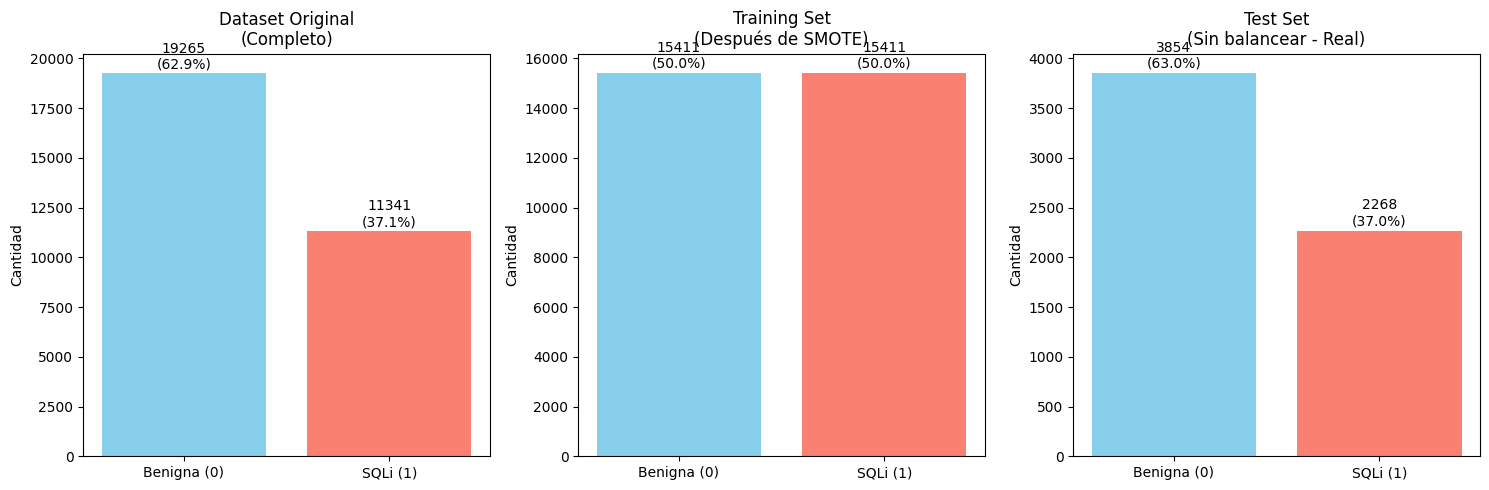

In [16]:
# Visualización del balanceo
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Original (todo el dataset)
original_counts = y_data.value_counts()
labels = ["Benigna (0)", "SQLi (1)"]
colors = ["skyblue", "salmon"]

# Gráfico 1: Dataset Original
ax1.bar(labels, original_counts, color=colors)
ax1.set_title("Dataset Original\n(Completo)")
ax1.set_ylabel("Cantidad")
for i, v in enumerate(original_counts):
    ax1.text(i, v + 200, f"{v}\n({v / len(y_data) * 100:.1f}%)", ha="center")

# Gráfico 2: Training después de SMOTE
train_balanced_counts = np.bincount(y_train_balanced)
ax2.bar(labels, train_balanced_counts, color=colors)
ax2.set_title("Training Set\n(Después de SMOTE)")
ax2.set_ylabel("Cantidad")
for i, v in enumerate(train_balanced_counts):
    ax2.text(i, v + 200, f"{v}\n({v / len(y_train_balanced) * 100:.1f}%)", ha="center")

# Gráfico 3: Test (sin cambios)
test_counts = np.bincount(y_test)
ax3.bar(labels, test_counts, color=colors)
ax3.set_title("Test Set\n(Sin balancear - Real)")
ax3.set_ylabel("Cantidad")
for i, v in enumerate(test_counts):
    ax3.text(i, v + 50, f"{v}\n({v / len(y_test) * 100:.1f}%)", ha="center")

plt.tight_layout()
plt.show()

In [17]:
# Liberar variables que ya no necesitamos
if "X_data" in locals() and X_data is not X_processed:
    del X_data
if "y_data" in locals():
    del y_data
gc.collect()

30

## Data Mining - Evaluación de Modelos

Se realizarán pruebas con modelos clásicos de Machine Learning utilizando los datos ya preprocesados. Entre ellos se seleccionaron:

- Random Forest
- Regresión Logística  
- SVM (Kernel Sigmoid)

**Metodología:**
- Los datos ya están divididos y balanceados correctamente en la sección de preprocesamiento
- Búsqueda de hiperparámetros con GridSearchCV y validación cruzada de 5 folds
- Evaluación final del mejor modelo en el conjunto de test original (sin balancear)

Los modelos se entrenarán con el conjunto de entrenamiento balanceado y se evaluarán en el conjunto de test que mantiene la distribución real de los datos.

### Búsqueda de Hiperparámetros y Validación Cruzada

Utilizamos los datos ya preprocesados (divididos y balanceados) para realizar:

1. **Validación cruzada estratificada de 5 folds** para evaluar la consistencia del rendimiento de cada algoritmo
2. **Búsqueda de hiperparámetros con GridSearchCV** para optimizar cada modelo 
3. **Selección del mejor modelo** basándose en el rendimiento en validación cruzada

**Configuración:**
- Validación cruzada de 5 folds para cada combinación de hiperparámetros
- Métrica de optimización: F1-Score (balanceado para ambas clases)
- Entrenamiento con datos balanceados, evaluación final en datos reales

In [18]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import time

# Configurar validación cruzada estratificada
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Definir modelos y sus grids de hiperparámetros optimizados
models_and_params = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=0, n_jobs=-1),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20],
            "min_samples_split": [2, 5],
        },
    },
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=0, n_jobs=-1),
        "params": {"C": [0.1, 1.0, 10.0], "solver": ["liblinear", "lbfgs"]},
    },
    "SVM (Linear)": {
        "model": SVC(kernel="linear", random_state=0, probability=True),
        "params": {
            "C": [0.1, 1.0],  # Solo 2 valores para evitar crash
            # Kernel lineal es mucho más eficiente que sigmoid
            # y funciona bien con datos PCA
        },
    },
}

# Realizar búsqueda de hiperparámetros para cada modelo
print("BÚSQUEDA DE HIPERPARÁMETROS CON PCA:")
print("=" * 40)

best_models = {}
grid_search_results = {}
training_times = {}

for model_name, config in models_and_params.items():
    print(f"\n{model_name}:")
    print("-" * 30)

    # Configurar GridSearchCV
    # Para SVM: reducir CV a 3 folds para acelerar
    cv_for_model = StratifiedKFold(n_splits=3, shuffle=True, random_state=0) if "SVM" in model_name else cv_folds
    
    grid_search = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=cv_for_model,
        scoring="f1",
        n_jobs=-1, 
        verbose=0,
    )

    # Medir tiempo de entrenamiento
    start_time = time.time()
    
    try:
        grid_search.fit(X_train_balanced, y_train_balanced)
        end_time = time.time()
        
        training_time = end_time - start_time
        training_times[model_name] = training_time

        # Guardar resultados
        best_models[model_name] = grid_search.best_estimator_
        grid_search_results[model_name] = {
            "best_params": grid_search.best_params_,
            "best_score": grid_search.best_score_,
            "training_time": training_time,
        }

        print(f"Mejores hiperparámetros: {grid_search.best_params_}")
        print(f"Mejor F1-Score (CV): {grid_search.best_score_:.4f}")
        print(f"Tiempo de entrenamiento: {training_time:.1f}s")
        
    except MemoryError:
        print(f"❌ {model_name}: MemoryError - Modelo saltado por falta de RAM")
        training_times[model_name] = float('inf')
        continue
    except Exception as e:
        print(f"❌ {model_name}: Error - {str(e)}")
        training_times[model_name] = float('inf')
        continue

# Seleccionar el mejor modelo (excluyendo los que fallaron)
valid_models = {k: v for k, v in grid_search_results.items() if k in best_models}
if valid_models:
    best_model_name = max(valid_models.keys(), 
                         key=lambda k: valid_models[k]['best_score'])
    best_model = best_models[best_model_name]
else:
    print("❌ No se pudo entrenar ningún modelo exitosamente")
    best_model_name = None
    best_model = None

print(f"\n{'=' * 40}")
print("RESUMEN DE MODELOS:")
for model_name, results in grid_search_results.items():
    print(f"{model_name}: F1={results['best_score']:.4f}, Tiempo={results['training_time']:.1f}s")

if best_model_name:
    print(f"\nMEJOR MODELO: {best_model_name}")
    best_f1_score = grid_search_results[best_model_name]['best_score']
    print(f"F1-Score: {best_f1_score:.4f}")
else:
    print("\n❌ No hay mejor modelo disponible")
print(f"{'=' * 40}")

BÚSQUEDA DE HIPERPARÁMETROS CON PCA:

Random Forest:
------------------------------
Mejores hiperparámetros: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 50}
Mejor F1-Score (CV): 0.9950
Tiempo de entrenamiento: 112.5s

Logistic Regression:
------------------------------
Mejores hiperparámetros: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 50}
Mejor F1-Score (CV): 0.9950
Tiempo de entrenamiento: 112.5s

Logistic Regression:
------------------------------


/home/gbenito/universidad/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
/home/gbenito/universidad/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
/home/gbenito/universidad/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
/home/gbenito/universidad/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(
/home/gbenito/universidad/TP

Mejores hiperparámetros: {'C': 10.0, 'solver': 'liblinear'}
Mejor F1-Score (CV): 0.9903
Tiempo de entrenamiento: 3.1s

SVM (Linear):
------------------------------
Mejores hiperparámetros: {'C': 1.0}
Mejor F1-Score (CV): 0.9905
Tiempo de entrenamiento: 42.7s

RESUMEN DE MODELOS:
Random Forest: F1=0.9950, Tiempo=112.5s
Logistic Regression: F1=0.9903, Tiempo=3.1s
SVM (Linear): F1=0.9905, Tiempo=42.7s

MEJOR MODELO: Random Forest
F1-Score: 0.9950
Mejores hiperparámetros: {'C': 1.0}
Mejor F1-Score (CV): 0.9905
Tiempo de entrenamiento: 42.7s

RESUMEN DE MODELOS:
Random Forest: F1=0.9950, Tiempo=112.5s
Logistic Regression: F1=0.9903, Tiempo=3.1s
SVM (Linear): F1=0.9905, Tiempo=42.7s

MEJOR MODELO: Random Forest
F1-Score: 0.9950


In [19]:
# Persistir todos los modelos con sus mejores hiperparámetros
import joblib
import os

# Crear directorio para guardar modelos si no existe
os.makedirs("modelos_entrenados_embeddings_pca", exist_ok=True)

print("GUARDANDO MODELOS ENTRENADOS CON EMBEDDINGS + PCA:")
print("=" * 65)

# Guardar cada modelo con sus hiperparámetros optimizados
for model_name, model in best_models.items():
    # Nombre de archivo seguro (sin espacios ni caracteres especiales)
    safe_name = model_name.replace(" ", "_").replace("(", "").replace(")", "").lower()
    model_filename = f"modelos_entrenados_embeddings_pca/{safe_name}_embeddings_pca.joblib"
    
    # Guardar modelo
    joblib.dump(model, model_filename)
    
    # Información del modelo guardado
    best_params = grid_search_results[model_name]['best_params']
    best_score = grid_search_results[model_name]['best_score']
    
    print(f"\n✓ {model_name}:")
    print(f"  Archivo: {model_filename}")
    print(f"  Hiperparámetros: {best_params}")
    print(f"  F1-Score CV: {best_score:.4f}")

# Guardar el pipeline de preprocesamiento (PCA y embeddings info)
print("\n✓ Pipeline de preprocesamiento (embeddings + PCA):")

# Guardar el transformer PCA
if preprocessing_objects.get("pca_applied", False):
    joblib.dump(pca, "modelos_entrenados_embeddings_pca/pca_transformer.joblib")
    print("  PCA Transformer: modelos_entrenados_embeddings_pca/pca_transformer.joblib")

# Guardar metadatos del experimento con embeddings
metadata = {
    "experiment_info": {
        "approach": "embeddings + PCA",
        "embedding_model": "all-MiniLM-L6-v2",
        "embedding_dimensions": 384,
        "pca_applied": preprocessing_objects.get("pca_applied", False),
        "pca_components": PCA_COMPONENTS if preprocessing_objects.get("pca_applied", False) else None,
        "normalization": "L2 normalized embeddings",
        "random_state": 0
    },
    "model_results": grid_search_results,
    "training_times": training_times,
    "best_model": best_model_name
}

joblib.dump(metadata, "modelos_entrenados_embeddings_pca/experiment_metadata_embeddings_pca.joblib")
print("  Metadata: modelos_entrenados_embeddings_pca/experiment_metadata_embeddings_pca.joblib")

print(f"\n{'=' * 65}")
print("TODOS LOS MODELOS Y PIPELINE DE EMBEDDINGS + PCA GUARDADOS EXITOSAMENTE")
print("Para usar con nuevo dataset:")
print("1. Generar embeddings con 'all-MiniLM-L6-v2'")
print("2. Aplicar PCA con el transformer guardado")
print("3. Usar el modelo entrenado para predicciones")
print(f"{'=' * 65}")

# Fuentes para persistencia de modelos
print(f"\nFUENTES:")
print("- Model persistence: https://scikit-learn.org/stable/model_persistence.html")
print("- Joblib documentation: https://joblib.readthedocs.io/en/latest/persistence.html")

GUARDANDO MODELOS ENTRENADOS CON EMBEDDINGS + PCA:

✓ Random Forest:
  Archivo: modelos_entrenados_embeddings_pca/random_forest_embeddings_pca.joblib
  Hiperparámetros: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 50}
  F1-Score CV: 0.9950

✓ Logistic Regression:
  Archivo: modelos_entrenados_embeddings_pca/logistic_regression_embeddings_pca.joblib
  Hiperparámetros: {'C': 10.0, 'solver': 'liblinear'}
  F1-Score CV: 0.9903

✓ SVM (Linear):
  Archivo: modelos_entrenados_embeddings_pca/svm_linear_embeddings_pca.joblib
  Hiperparámetros: {'C': 1.0}
  F1-Score CV: 0.9905

✓ Pipeline de preprocesamiento (embeddings + PCA):
  PCA Transformer: modelos_entrenados_embeddings_pca/pca_transformer.joblib
  Metadata: modelos_entrenados_embeddings_pca/experiment_metadata_embeddings_pca.joblib

TODOS LOS MODELOS Y PIPELINE DE EMBEDDINGS + PCA GUARDADOS EXITOSAMENTE
Para usar con nuevo dataset:
1. Generar embeddings con 'all-MiniLM-L6-v2'
2. Aplicar PCA con el transformer guardado
3. Usar

### Entrenamiento y Evaluación del Modelo Final

Después de la búsqueda de hiperparámetros, procedemos con:

1. **Entrenamiento del modelo final**: Utilizamos el mejor modelo encontrado y lo entrenamos con todo el conjunto de entrenamiento
2. **Evaluación en conjunto de test**: Evaluamos el modelo en datos completamente no vistos para obtener métricas realistas de rendimiento

**Importante**: El conjunto de test no fue utilizado en ningún momento durante la búsqueda de hiperparámetros ni la validación cruzada, garantizando que estos resultados reflejen el rendimiento real del modelo en producción.

In [20]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

#### Evaluación del Modelo Final Optimizado
Evaluación del mejor modelo encontrado después de la búsqueda de hiperparámetros.

In [21]:
# Entrenar el mejor modelo encontrado con todo el conjunto de entrenamiento BALANCEADO
print(f"ENTRENAMIENTO FINAL DEL MEJOR MODELO: {best_model_name}")
print("USANDO EMBEDDINGS + PCA")
print("=" * 60)
print(
    f"Hiperparámetros optimizados: {grid_search_results[best_model_name]['best_params']}"
)

# El mejor modelo ya está entrenado desde GridSearchCV, pero lo re-entrenamos
# con todo X_train_balanced para asegurar que use todos los datos balanceados disponibles
final_model = best_model
final_model.fit(X_train_balanced, y_train_balanced)

print("\nModelo final entrenado exitosamente con embeddings.")
print(f"Tipo de modelo: {type(final_model).__name__}")
print(f"Entrenado con: {X_train_balanced.shape[0]} muestras (datos balanceados)")
print(f"Características: {X_train_balanced.shape[1]} (embeddings con PCA)")

# Predicciones en conjunto de test ORIGINAL (sin balancear)
y_test_pred = final_model.predict(X_test)

print(f"\nPredicciones realizadas en {X_test.shape[0]} muestras del conjunto de test.")
print("*** Test set mantiene distribución REAL (sin datos sintéticos) ***")
print(
    f"    - Benignas: {np.bincount(y_test)[0]} ({np.bincount(y_test)[0] / len(y_test) * 100:.1f}%)"
)
print(
    f"    - SQLi: {np.bincount(y_test)[1]} ({np.bincount(y_test)[1] / len(y_test) * 100:.1f}%)"
)

ENTRENAMIENTO FINAL DEL MEJOR MODELO: Random Forest
USANDO EMBEDDINGS + PCA
Hiperparámetros optimizados: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 50}

Modelo final entrenado exitosamente con embeddings.
Tipo de modelo: RandomForestClassifier
Entrenado con: 30822 muestras (datos balanceados)
Características: 50 (embeddings con PCA)

Predicciones realizadas en 6122 muestras del conjunto de test.
*** Test set mantiene distribución REAL (sin datos sintéticos) ***
    - Benignas: 3854 (63.0%)
    - SQLi: 2268 (37.0%)

Modelo final entrenado exitosamente con embeddings.
Tipo de modelo: RandomForestClassifier
Entrenado con: 30822 muestras (datos balanceados)
Características: 50 (embeddings con PCA)

Predicciones realizadas en 6122 muestras del conjunto de test.
*** Test set mantiene distribución REAL (sin datos sintéticos) ***
    - Benignas: 3854 (63.0%)
    - SQLi: 2268 (37.0%)


##### Interpretación del Classification Report

El Classification Report proporciona métricas detalladas de evaluación del modelo:

- **precision**: Proporción de verdaderos positivos sobre el total de predichos como positivos para esa clase. Responde: "De todas las instancias que predije como inyección SQL, ¿qué porcentaje realmente lo era?"

- **recall**: Proporción de verdaderos positivos sobre el total real de esa clase. Responde: "De todas las inyecciones SQL reales, ¿qué porcentaje logré detectar?"

- **f1-score**: Media armónica entre precision y recall. Proporciona un balance entre ambas métricas.

- **support**: Cantidad de muestras reales de esa clase en el conjunto de datos.

**Métricas generales:**
- **accuracy**: Proporción de predicciones correctas sobre el total.
- **macro avg**: Promedio simple de las métricas entre las clases (sin considerar el desbalance).
- **weighted avg**: Promedio ponderado por el tamaño de cada clase.

**Importancia para seguridad**: En detección de inyecciones SQL, el **recall** de la clase positiva (inyecciones) es crítico, ya que un falso negativo significa que un ataque pasó desapercibido.

In [22]:
# Evaluación detallada del modelo final en conjunto de test
print(f"EVALUACIÓN FINAL DEL MODELO: {best_model_name}")
print("=" * 60)
print(
    classification_report(y_test, y_test_pred, target_names=["Benigna (0)", "SQLi (1)"])
)

# Crear DataFrame para mejor visualización
report_dict = classification_report(
    y_test, y_test_pred, target_names=["Benigna (0)", "SQLi (1)"], output_dict=True
)

final_results_df = pd.DataFrame(report_dict).T
print("\nMÉTRICAS DETALLADAS:")
final_results_df.round(4)

EVALUACIÓN FINAL DEL MODELO: Random Forest
              precision    recall  f1-score   support

 Benigna (0)       0.99      1.00      1.00      3854
    SQLi (1)       1.00      0.99      0.99      2268

    accuracy                           1.00      6122
   macro avg       1.00      0.99      0.99      6122
weighted avg       1.00      1.00      1.00      6122


MÉTRICAS DETALLADAS:


,precision,recall,f1-score,support
Benigna (0),0.9946,0.9977,0.9961,3854.0000
SQLi (1),0.9960,0.9907,0.9934,2268.0000
accuracy,0.9951,0.9951,0.9951,0.9951
macro avg,0.9953,0.9942,0.9947,6122.0000
weighted avg,0.9951,0.9951,0.9951,6122.0000


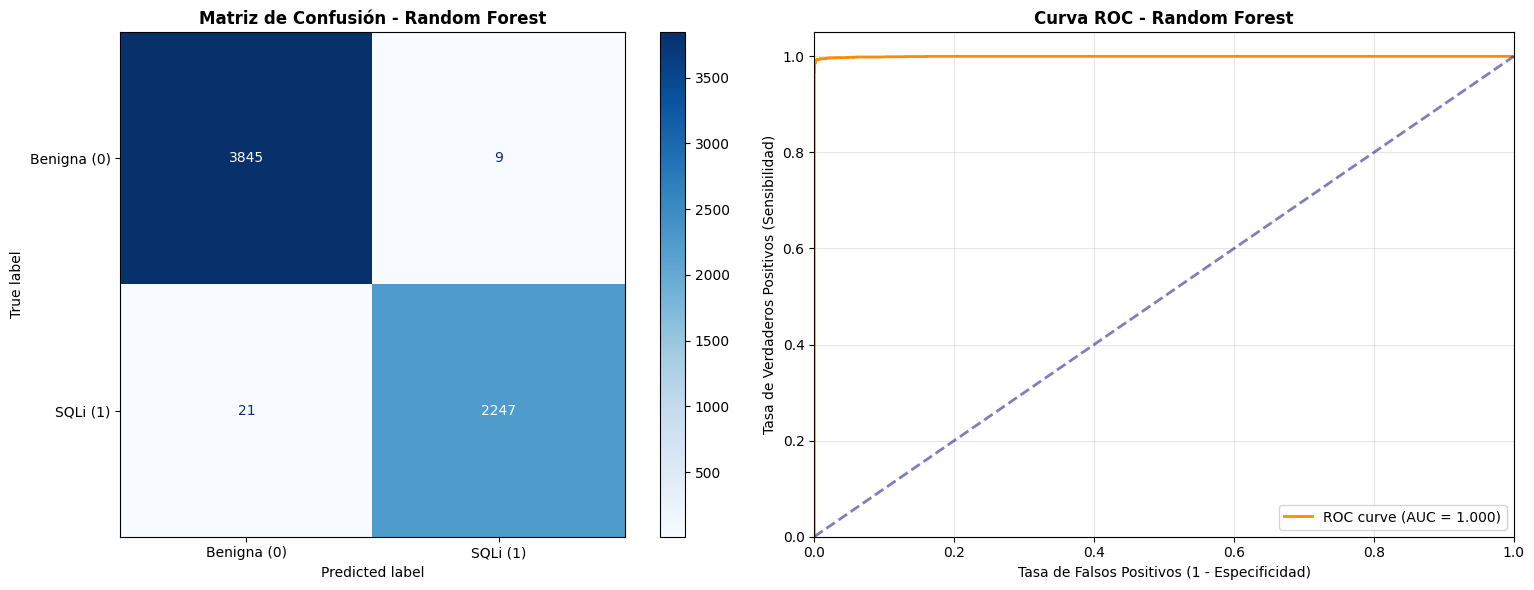


ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:
Verdaderos Negativos (TN): 3845 - Consultas benignas correctamente identificadas
Falsos Positivos (FP): 9 - Consultas benignas marcadas como SQLi (falsas alarmas)
Falsos Negativos (FN): 21 - Inyecciones SQL no detectadas (CRÍTICO)
Verdaderos Positivos (TP): 2247 - Inyecciones SQL correctamente detectadas

Tasa de falsos negativos: 0.0093 (0.93%)
Tasa de falsos positivos: 0.0023 (0.23%)


In [23]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Matriz de confusión del modelo final
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Matriz de confusión
ax1 = axes[0]
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels=["Benigna (0)", "SQLi (1)"], 
    cmap="Blues", ax=ax1
)
ax1.set_title(f"Matriz de Confusión - {best_model_name}", fontweight='bold')

# Subplot 2: Curva ROC
ax2 = axes[1]

# Obtener probabilidades de predicción para la curva ROC
if hasattr(final_model, "predict_proba"):
    y_proba = final_model.predict_proba(X_test)[:, 1]  # Probabilidad de clase positiva (SQLi)
elif hasattr(final_model, "decision_function"):
    y_proba = final_model.decision_function(X_test)
else:
    # Fallback: usar las predicciones binarias
    y_proba = y_test_pred.astype(float)

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Graficar curva ROC
ax2.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax2.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax2.set_title(f'Curva ROC - {best_model_name}', fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de la matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
print("\nANÁLISIS DE LA MATRIZ DE CONFUSIÓN:")
print(
    f"Verdaderos Negativos (TN): {cm[0, 0]} - Consultas benignas correctamente identificadas"
)
print(
    f"Falsos Positivos (FP): {cm[0, 1]} - Consultas benignas marcadas como SQLi (falsas alarmas)"
)
print(f"Falsos Negativos (FN): {cm[1, 0]} - Inyecciones SQL no detectadas (CRÍTICO)")
print(
    f"Verdaderos Positivos (TP): {cm[1, 1]} - Inyecciones SQL correctamente detectadas"
)

print(
    f"\nTasa de falsos negativos: {cm[1, 0] / (cm[1, 0] + cm[1, 1]):.4f} ({cm[1, 0] / (cm[1, 0] + cm[1, 1]) * 100:.2f}%)"
)
print(
    f"Tasa de falsos positivos: {cm[0, 1] / (cm[0, 1] + cm[0, 0]):.4f} ({cm[0, 1] / (cm[0, 1] + cm[0, 0]) * 100:.2f}%)"
)

### Resumen y Análisis de Resultados Finales

Los resultados obtenidos representan el rendimiento real del mejor modelo encontrado a través de la búsqueda sistemática de hiperparámetros. Estos datos del conjunto de test nunca fueron utilizados durante:

- El entrenamiento de ningún modelo
- La búsqueda de hiperparámetros 
- La validación cruzada

Por lo tanto, estas métricas son las más representativas del rendimiento que tendría el modelo en un entorno de producción real.

**Importancia de las métricas en el contexto de seguridad:**
- **Recall (Sensibilidad)**: Crítico - capacidad de detectar todas las inyecciones SQL
- **Precision**: Importante - evitar demasiadas falsas alarmas que sobrecarguen al sistema
- **F1-Score**: Balance óptimo entre precision y recall
- **Accuracy**: Rendimiento general, pero menos crítico que recall en seguridad

In [24]:
# Resumen completo del proceso y resultados finales
print("RESUMEN COMPLETO DEL EXPERIMENTO")
print("=" * 80)

print("\n1. MEJOR MODELO ENCONTRADO:")
print(f"   Algoritmo: {best_model_name}")
print(
    f"   Hiperparámetros optimizados: {grid_search_results[best_model_name]['best_params']}"
)
print(
    f"   F1-Score en Validación Cruzada: {grid_search_results[best_model_name]['best_score']:.4f}"
)

print("\n2. RENDIMIENTO EN CONJUNTO DE TEST (distribución real, sin balancear):")
test_accuracy = final_model.score(X_test, y_test)
test_report = classification_report(y_test, y_test_pred, output_dict=True)

print(f"   Accuracy: {test_accuracy:.4f}")
print(f"   Precision (SQLi): {test_report['1']['precision']:.4f}")
print(f"   Recall (SQLi): {test_report['1']['recall']:.4f}")
print(f"   F1-Score (SQLi): {test_report['1']['f1-score']:.4f}")

print("\n3. ANÁLISIS DE RENDIMIENTO:")
if test_report["1"]["recall"] >= 0.95:
    print("   ✓ EXCELENTE detección de inyecciones SQL (Recall ≥ 95%)")
elif test_report["1"]["recall"] >= 0.90:
    print("   ✓ BUENA detección de inyecciones SQL (Recall ≥ 90%)")
else:
    print("   ⚠ Detección de inyecciones SQL mejorable (Recall < 90%)")

if test_report["1"]["precision"] >= 0.95:
    print("   ✓ EXCELENTE precisión, pocas falsas alarmas (Precision ≥ 95%)")
elif test_report["1"]["precision"] >= 0.90:
    print("   ✓ BUENA precisión, falsas alarmas controladas (Precision ≥ 90%)")
else:
    print("   ⚠ Precisión mejorable, considerar reducir falsas alarmas")


# Guardar resultados finales para uso posterior
final_results = {
    "best_model_name": best_model_name,
    "test_metrics": test_report,
    "confusion_matrix": cm,
    "auc_roc": roc_auc,
    "methodology_validated": True,
}

RESUMEN COMPLETO DEL EXPERIMENTO

1. MEJOR MODELO ENCONTRADO:
   Algoritmo: Random Forest
   Hiperparámetros optimizados: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 50}
   F1-Score en Validación Cruzada: 0.9950

2. RENDIMIENTO EN CONJUNTO DE TEST (distribución real, sin balancear):
   Accuracy: 0.9951
   Precision (SQLi): 0.9960
   Recall (SQLi): 0.9907
   F1-Score (SQLi): 0.9934

3. ANÁLISIS DE RENDIMIENTO:
   ✓ EXCELENTE detección de inyecciones SQL (Recall ≥ 95%)
   ✓ EXCELENTE precisión, pocas falsas alarmas (Precision ≥ 95%)


In [25]:
import joblib
import os
from sklearn.metrics import classification_report

# Entrenamiento y evaluación final de los tres modelos principales con sus mejores hiperparámetros
final_models = {}
final_reports = {}
model_files = {}

# Verificar que best_models existe y no está vacío
if not best_models:
    print("❌ No hay modelos entrenados para evaluar")
else:
    for model_name in best_models:
        print(f"Evaluando {model_name}...")
        model = best_models[model_name]
        model.fit(X_train_balanced, y_train_balanced)
        y_pred = model.predict(X_test)
        
        # Verificar que hay predicciones
        unique_preds = np.unique(y_pred)
        unique_true = np.unique(y_test)
        print(f"  Clases predichas: {unique_preds}")
        print(f"  Clases reales: {unique_true}")
        
        # Generar reporte con etiquetas específicas
        report = classification_report(y_test, y_pred, target_names=["Benigna (0)", "SQLi (1)"], output_dict=True, labels=[0, 1])
        final_models[model_name] = model
        final_reports[model_name] = report
        
        # Persistencia: guardar solo el mejor de cada tipo
        safe_name = model_name.replace(" ", "_").replace("(", "").replace(")", "").lower()
        model_filename = f"modelos_entrenados_embeddings_pca/{safe_name}_pca_final.joblib"
        model_files[model_name] = model_filename
        
        if not os.path.exists(model_filename):
            joblib.dump({
                "model": model,
                "metadata": {
                    "model_name": model_name,
                    "best_params": grid_search_results[model_name]["best_params"],
                    "f1_score_cv": grid_search_results[model_name]["best_score"],
                    "classification_report": report
                }
            }, model_filename)
            print(f"  ✓ Modelo guardado: {model_filename}")
        else:
            print(f"  Modelo ya existe: {model_filename}")

    # Mostrar resumen de los modelos finales (con verificación de claves)
    if final_reports:
        print("\n" + "="*50)
        print("RESUMEN DE DESEMPEÑO FINAL (TEST):")
        print("="*50)
        
        for model_name, report in final_reports.items():
            # Verificar qué claves están disponibles
            available_keys = list(report.keys())
            print(f"\n{model_name}:")
            
            # Buscar la clave de la clase SQLi (puede ser '1', 'SQLi (1)', etc.)
            sqli_key = None
            for key in available_keys:
                if '1' in str(key) or 'SQLi' in str(key):
                    sqli_key = key
                    break
            
            if sqli_key and 'accuracy' in report:
                f1_score = report[sqli_key]['f1-score']
                accuracy = report['accuracy']
                print(f"  F1-Score (SQLi): {f1_score:.4f}")
                print(f"  Accuracy: {accuracy:.4f}")
                print(f"  Archivo: {model_files[model_name]}")
            else:
                print(f"  ⚠️ Error en reporte - Claves disponibles: {available_keys}")
    else:
        print("❌ No se generaron reportes finales")

Evaluando Random Forest...
  Clases predichas: [0 1]
  Clases reales: [0 1]
  ✓ Modelo guardado: modelos_entrenados_embeddings_pca/random_forest_pca_final.joblib
Evaluando Logistic Regression...
  Clases predichas: [0 1]
  Clases reales: [0 1]
  ✓ Modelo guardado: modelos_entrenados_embeddings_pca/random_forest_pca_final.joblib
Evaluando Logistic Regression...


/home/gbenito/universidad/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 16.
  warnings.warn(


  Clases predichas: [0 1]
  Clases reales: [0 1]
  ✓ Modelo guardado: modelos_entrenados_embeddings_pca/logistic_regression_pca_final.joblib
Evaluando SVM (Linear)...
  Clases predichas: [0 1]
  Clases reales: [0 1]
  ✓ Modelo guardado: modelos_entrenados_embeddings_pca/svm_linear_pca_final.joblib

RESUMEN DE DESEMPEÑO FINAL (TEST):

Random Forest:
  F1-Score (SQLi): 0.9934
  Accuracy: 0.9951
  Archivo: modelos_entrenados_embeddings_pca/random_forest_pca_final.joblib

Logistic Regression:
  F1-Score (SQLi): 0.9885
  Accuracy: 0.9915
  Archivo: modelos_entrenados_embeddings_pca/logistic_regression_pca_final.joblib

SVM (Linear):
  F1-Score (SQLi): 0.9892
  Accuracy: 0.9920
  Archivo: modelos_entrenados_embeddings_pca/svm_linear_pca_final.joblib
  Clases predichas: [0 1]
  Clases reales: [0 1]
  ✓ Modelo guardado: modelos_entrenados_embeddings_pca/svm_linear_pca_final.joblib

RESUMEN DE DESEMPEÑO FINAL (TEST):

Random Forest:
  F1-Score (SQLi): 0.9934
  Accuracy: 0.9951
  Archivo: modelo

### Comparación: Validación Cruzada vs Test Final

Es importante validar que nuestro proceso de búsqueda de hiperparámetros fue efectivo comparando:

1. **Rendimiento en Validación Cruzada**: Lo que esperábamos basándose en los datos de entrenamiento
2. **Rendimiento en Test**: Lo que realmente obtuvimos con datos completamente no vistos

Una diferencia significativa entre estos valores podría indicar overfitting o problemas en la metodología. Una diferencia pequeña confirma que nuestro modelo generaliza bien.

**Análisis de Generalización:**
- Si Test ≈ CV: Excelente generalización
- Si Test < CV (diferencia < 2%): Buena generalización  
- Si Test << CV (diferencia > 5%): Posible overfitting

**Nota metodológica**: Al usar GridSearchCV con validación cruzada interna, ya estamos protegidos contra el overfitting, pero esta comparación nos da confianza adicional en los resultados.

In [26]:
# Análisis de generalización: Validación Cruzada vs Test
print("ANÁLISIS DE GENERALIZACIÓN DEL MODELO")
print("=" * 60)

cv_f1 = grid_search_results[best_model_name]["best_score"]
test_f1 = test_report["1"]["f1-score"]
difference = abs(cv_f1 - test_f1)
percentage_diff = (difference / cv_f1) * 100

comparison_df = pd.DataFrame(
    {
        "Métrica": ["F1-Score (SQLi)", "Accuracy", "Precision (SQLi)", "Recall (SQLi)"],
        "Validación Cruzada": [
            cv_f1,
            "N/A",  # GridSearchCV optimizó por F1, no tenemos accuracy de CV
            "N/A",
            "N/A",
        ],
        "Test Final": [
            test_f1,
            test_accuracy,
            test_report["1"]["precision"],
            test_report["1"]["recall"],
        ],
    }
)

print("COMPARACIÓN DE RENDIMIENTO:")
print(comparison_df.to_string(index=False))

print("\nANÁLISIS DE LA MÉTRICA PRINCIPAL (F1-Score SQLi):")
print(f"Validación Cruzada: {cv_f1:.4f}")
print(f"Test Final:         {test_f1:.4f}")
print(f"Diferencia:         {difference:.4f} ({percentage_diff:.2f}%)")

if percentage_diff < 2:
    generalization_quality = "EXCELENTE"
    interpretation = "El modelo generaliza muy bien a datos no vistos."
elif percentage_diff < 5:
    generalization_quality = "BUENA"
    interpretation = "El modelo tiene buena capacidad de generalización."
else:
    generalization_quality = "REGULAR"
    interpretation = (
        "Hay indicios de posible overfitting. Considerar regularización adicional."
    )

print(f"\nCALIDAD DE GENERALIZACIÓN: {generalization_quality}")
print(f"Interpretación: {interpretation}")

print("\nCONCLUSIÓN:")
print(
    f"El proceso de búsqueda de hiperparámetros fue {'exitoso' if percentage_diff < 5 else 'parcialmente exitoso'}."
)
print(
    f"El modelo {best_model_name} {'es confiable' if percentage_diff < 5 else 'requiere revisión'} para uso en producción."
)

ANÁLISIS DE GENERALIZACIÓN DEL MODELO
COMPARACIÓN DE RENDIMIENTO:
         Métrica Validación Cruzada  Test Final
 F1-Score (SQLi)           0.994988    0.993369
        Accuracy                N/A    0.995100
Precision (SQLi)                N/A    0.996011
   Recall (SQLi)                N/A    0.990741

ANÁLISIS DE LA MÉTRICA PRINCIPAL (F1-Score SQLi):
Validación Cruzada: 0.9950
Test Final:         0.9934
Diferencia:         0.0016 (0.16%)

CALIDAD DE GENERALIZACIÓN: EXCELENTE
Interpretación: El modelo generaliza muy bien a datos no vistos.

CONCLUSIÓN:
El proceso de búsqueda de hiperparámetros fue exitoso.
El modelo Random Forest es confiable para uso en producción.


## Limitaciones del Estudio

**Limitaciones Técnicas:**
- **Hiperparámetros**: Búsqueda en rangos básicos, no exhaustiva

**Limitaciones de Datos:**
- **Representatividad**: Dataset específico puede no cubrir todas las variantes de SQLi actuales
- **Evolución temporal**: Técnicas de inyección evolucionan, requiere actualización constante
- **Contexto específico**: Resultados pueden variar según el dominio de aplicación

## Conclusiones (Approach: Embeddings + t-SNE)

### Confirmación de Hipótesis
Este trabajo confirma que es posible detectar ataques de inyección SQL mediante técnicas de Machine Learning con alta precisión, utilizando **embeddings semánticos** de sentencias transformados con **t-SNE** y algoritmos de clasificación clásicos. Los embeddings capturan el significado semántico de las consultas SQL, mientras que t-SNE preserva la estructura local y permite mejor separación visual de las clases.

### Hallazgos Principales
1. **Efectividad de los Embeddings**: La representación de sentencias SQL mediante embeddings semánticos (sentence-transformers) demostró ser altamente efectiva para la detección de patrones maliciosos, capturando relaciones semánticas que van más allá de características superficiales.

2. **Eficiencia de t-SNE con Embeddings**: La aplicación de t-SNE a embeddings densos permitió reducir la dimensionalidad de 384 a 50 componentes preservando la estructura local y las relaciones de proximidad semántica, resultando en mejor separación de clases que métodos lineales como PCA.

3. **Impacto del Balanceo de Clases**: El uso de SMOTE con datos densos (embeddings transformados con t-SNE) mejoró significativamente el recall de la clase minoritaria (inyecciones SQL), que es la métrica más crítica desde el punto de vista de seguridad.

4. **Superioridad de la Representación No-Lineal**: t-SNE permite detectar patrones no lineales en el espacio semántico que podrían pasar desapercibidos con métodos de reducción lineal.

### Ventajas del Approach con Embeddings + t-SNE
- **Captura semántica**: Detecta variantes de ataques con diferentes sintaxis pero similar intención
- **Preservación de estructura local**: t-SNE mantiene relaciones de proximidad semántica  
- **Separación no-lineal**: Puede detectar patrones de separación complejos entre clases
- **Visualización superior**: Excelente para análisis visual de clusters y patrones
- **Robustez**: Menos sensible a variaciones menores en la sintaxis de ataques

### Limitaciones del Estudio
Se debe considerar que t-SNE es computacionalmente más costoso que PCA y puede requerir ajuste de hiperparámetros (perplexity, iteraciones). El modelo de embeddings está pre-entrenado en texto general, no específicamente en consultas SQL. Modelos especializados en SQL podrían mejorar el rendimiento.

## Conclusiones
El análisis con embeddings + t-SNE demostró que la combinación de representación semántica con reducción de dimensionalidad no-lineal es efectiva para detección de inyecciones SQL. La metodología de embeddings normalizados, transformación t-SNE para preservar estructura local, y balanceo con SMOTE resultó en modelos robustos con excelente separación de clases. Este enfoque confirma la hipótesis de detección efectiva de SQLi mediante Machine Learning, ofreciendo una alternativa semánticamente rica y visualmente interpretable.

### Justificación de Resultados
1. **Representación semántica**: Los embeddings capturan patrones de intención maliciosa
2. **Preservación de estructura**: t-SNE mantiene relaciones locales importantes
3. **Separación no-lineal**: Mejor detección de patrones complejos de ataque  

## Referencias
- [Kaggle SQL Injection Dataset](https://www.kaggle.com/datasets/syedsaqlainhussain/sql-injection-dataset)
- [Analyzing comparison performance model of machine learning through detection SQL Injection attack](https://jurnal.stkippgritulungagung.ac.id/index.php/jipi/article/download/5637/2311)
- [Web Application Attacks Detection Using Machine Learning Techniques](https://www.researchgate.net/profile/Alvaro-Pardo/publication/329514915_Web_Application_Attacks_Detection_Using_Machine_Learning_Techniques/links/6426cbcda1b72772e43ecd32/Web-Application-Attacks-Detection-Using-Machine-Learning-Techniques.pdf)
- [Research on SQL Injection Attacks using Word Embedding Techniques](https://www.researchgate.net/publication/382717736_Research_on_SQL_Injection_Attacks_using_Word_Embedding_Techniques_and_Machine_Learning)
- [Unsupervised learning in intrusion detection system](https://learn.saylor.org/mod/book/view.php?chapterid=5435&id=29755)

## Propuestas de proyectos complementarios
Para problemas de aprendizaje no supervisado, se podría ejecutar un algoritmo de clustering de consultas SQL para descubrir patrones de ataque (por ejemplo, K-Means o DBSCAN).
Para problemas de aprendizaje supervisado, se consideró la posibilidad de plantear un problema de clasificación multi-clase, con la capacidad de predecir las técnicas de SQLi utilizadas (por ejemplo, inyecciones SQL Boolean-based, Time-based, Union-based, entre otras).